<a href="https://colab.research.google.com/github/kyungeunvoyage/MotionDualAxisVib/blob/main/REReRERE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# === 0) Colab: Google Drive 마운트 ===
from google.colab import drive
drive.mount('/content/drive')

# === 1) 데이터 폴더 경로 설정 ===
# 예시) '/content/drive/MyDrive/YourDataFolder'
DATA_DIR = "/content/drive/MyDrive/2026 Haptics Symposium/00.Exploratory Study/Experiment Data"  # <-- 여기를 당신의 폴더 경로로 변경하세요.


Mounted at /content/drive


Loaded participants: 20 / files: 20


/tmp/ipython-input-3386110618.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_tbl = am.groupby('participant').apply(summarize).reset_index()


,participant,n_axis_match_trials,n_correct,accuracy_axis_match,accuracy_pct,ci_low_pct,ci_high_pct,error_rate_pct
0,P08,163.0,95.0,0.582822,58.3,50.6,65.6,41.7
1,P10,190.0,109.0,0.573684,57.4,50.3,64.2,42.6
2,P11,177.0,99.0,0.559322,55.9,48.6,63.0,44.1
3,P18,191.0,103.0,0.539267,53.9,46.8,60.8,46.1
4,P14,191.0,102.0,0.534031,53.4,46.3,60.3,46.6
5,P12,159.0,83.0,0.522013,52.2,44.5,59.8,47.8
6,P03,192.0,99.0,0.515625,51.6,44.5,58.5,48.4
7,P09,184.0,94.0,0.510870,51.1,43.9,58.2,48.9
8,P20,183.0,93.0,0.508197,50.8,43.6,58.0,49.2
9,P16,185.0,94.0,0.508108,50.8,43.7,57.9,49.2


Saved ranking CSV to: /content/drive/MyDrive/2026 Haptics Symposium/00.Exploratory Study/Experiment Data/results_axis_match_ranking/axis_match_accuracy_ranking_all_with_pct.csv
Saved plot: /content/drive/MyDrive/2026 Haptics Symposium/00.Exploratory Study/Experiment Data/results_axis_match_ranking/axis_match_accuracy_bar_all.png
Saved plot: /content/drive/MyDrive/2026 Haptics Symposium/00.Exploratory Study/Experiment Data/results_axis_match_ranking/axis_match_accuracy_hist_all.png
Saved plot: /content/drive/MyDrive/2026 Haptics Symposium/00.Exploratory Study/Experiment Data/results_axis_match_ranking/axis_match_trials_vs_acc_all.png


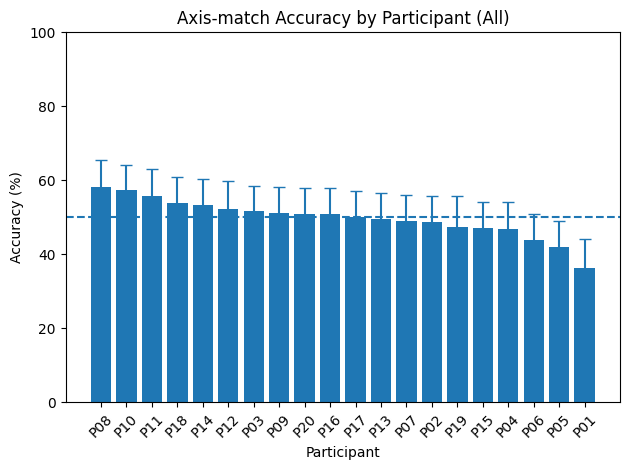

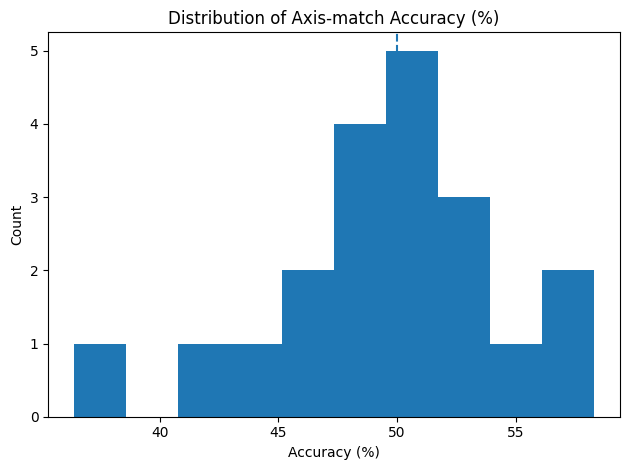

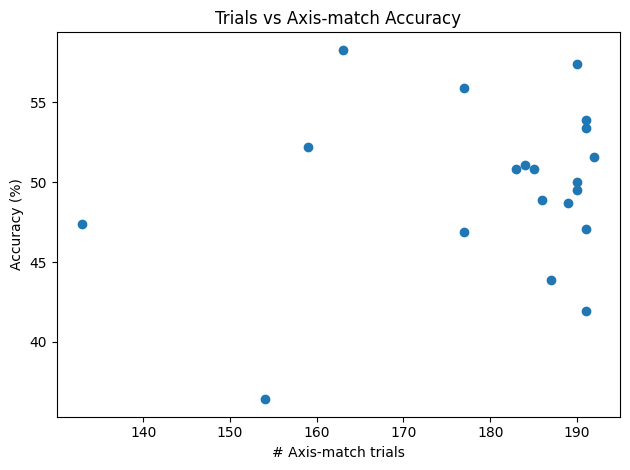

In [8]:
# === 2) 로드/클린/필터 & 랭킹(퍼센트 포함) ===
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# 모든 참가자 CSV 로드 (P01~P20 전체 같은 폴더에 있다고 가정)
files = sorted(glob.glob(os.path.join(DATA_DIR, "P*_exploratory_raw.csv")))
assert len(files) > 0, f"No CSV files found in {DATA_DIR}"

dfs = []
for f in files:
    d = pd.read_csv(f)
    pid = os.path.basename(f).split('_')[0]  # 'P07_exploratory_raw.csv' -> 'P07'
    d['participant'] = pid
    dfs.append(d)
raw = pd.concat(dfs, ignore_index=True)

# 숫자형 변환 & 결측 제거
for col in ['axis_match', 'correct']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')
raw = raw.dropna(subset=['axis_match','correct'])

# axis_match == 1 (축 일치 시도만)
am = raw[raw['axis_match'] == 1].copy()

# 참가자별 요약 함수 (퍼센트 + Wilson CI 포함)
def summarize(g):
    n = len(g)
    k = int(g['correct'].sum())
    acc = k / n if n > 0 else float('nan')
    low, high = proportion_confint(k, n, method='wilson') if n > 0 else (float('nan'), float('nan'))
    return pd.Series({
        'n_axis_match_trials': n,
        'n_correct': k,
        'accuracy_axis_match': acc,
        'accuracy_pct': acc * 100 if n > 0 else float('nan'),
        'ci_low_pct': low * 100 if n > 0 else float('nan'),
        'ci_high_pct': high * 100 if n > 0 else float('nan'),
        'error_rate_pct': (1 - acc) * 100 if n > 0 else float('nan'),
    })

rank_tbl = am.groupby('participant').apply(summarize).reset_index()
rank_tbl = rank_tbl.sort_values(['accuracy_axis_match','n_correct'], ascending=[False, False]).reset_index(drop=True)

# 보기 좋게 반올림
for c in ['accuracy_pct','ci_low_pct','ci_high_pct','error_rate_pct']:
    rank_tbl[c] = rank_tbl[c].round(1)

print(f"Loaded participants: {raw['participant'].nunique()} / files: {len(files)}")
display(rank_tbl)

# === 3) 저장 ===
OUT_DIR = os.path.join(DATA_DIR, "results_axis_match_ranking")
os.makedirs(OUT_DIR, exist_ok=True)
rank_csv = os.path.join(OUT_DIR, "axis_match_accuracy_ranking_all_with_pct.csv")
rank_tbl.to_csv(rank_csv, index=False)
print("Saved ranking CSV to:", rank_csv)

# === 4) 시각화 (matplotlib; 각 차트는 단일 플롯, 색상 지정 안 함) ===

# (A) 참가자별 정확도 막대 + Wilson CI 에러바
x = rank_tbl['participant']
y = rank_tbl['accuracy_pct']
yerr_lower = y - rank_tbl['ci_low_pct']
yerr_upper = rank_tbl['ci_high_pct'] - y
yerr = [yerr_lower, yerr_upper]

plt.figure()
plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt='none', capsize=4)
plt.axhline(50, linestyle='--')  # chance level
plt.title("Axis-match Accuracy by Participant (All)")
plt.xlabel("Participant")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plot_path = os.path.join(OUT_DIR, "axis_match_accuracy_bar_all.png")
plt.savefig(plot_path, dpi=150)
print("Saved plot:", plot_path)

# (B) 정확도(%) 분포 히스토그램
plt.figure()
plt.hist(rank_tbl['accuracy_pct'].dropna(), bins=10)
plt.axvline(50, linestyle='--')  # chance reference
plt.title("Distribution of Axis-match Accuracy (%)")
plt.xlabel("Accuracy (%)")
plt.ylabel("Count")
plt.tight_layout()
hist_path = os.path.join(OUT_DIR, "axis_match_accuracy_hist_all.png")
plt.savefig(hist_path, dpi=150)
print("Saved plot:", hist_path)

# (C) 참가자별 trial 수 vs 정확도 산점도
plt.figure()
plt.scatter(rank_tbl['n_axis_match_trials'], rank_tbl['accuracy_pct'])
plt.title("Trials vs Axis-match Accuracy")
plt.xlabel("# Axis-match trials")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
scat_path = os.path.join(OUT_DIR, "axis_match_trials_vs_acc_all.png")
plt.savefig(scat_path, dpi=150)
print("Saved plot:", scat_path)